In [22]:
import warnings
warnings.filterwarnings('ignore')

In [23]:
import geopandas as gpd
br = gpd.read_file('http://darribas.org/gds19/content/labs/data/brexit.gpkg').set_index('LAD14CD', drop=False)
br.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 380 entries, E06000001 to W06000024
Data columns (total 25 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    380 non-null    int32   
 1   LAD14CD     380 non-null    str     
 2   LAD14NM     380 non-null    str     
 3   LAD14NMW    22 non-null     str     
 4   id          380 non-null    int32   
 5   Region_Cod  380 non-null    str     
 6   Region      380 non-null    str     
 7   Area        380 non-null    str     
 8   Electorate  380 non-null    int32   
 9   ExpectedBa  380 non-null    int32   
 10  VerifiedBa  380 non-null    int32   
 11  Pct_Turnou  380 non-null    float64 
 12  Votes_Cast  380 non-null    int32   
 13  Valid_Vote  380 non-null    int32   
 14  Remain      380 non-null    int32   
 15  Leave       380 non-null    int32   
 16  Rejected_B  380 non-null    int32   
 17  No_officia  380 non-null    int32   
 18  Voting_for  380 non-null    int32

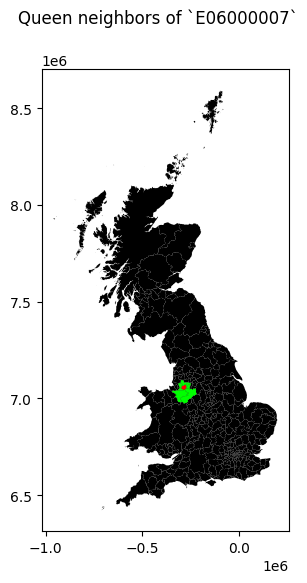

In [24]:
from libpysal import weights
w_queen = weights.Queen.from_dataframe(br, idVariable="LAD14CD")
w_queen

import matplotlib.pyplot as plt

# Setup figure
f, ax = plt.subplots(1, figsize=(6, 6))

# Plot base layer of polygons
br.plot(ax=ax, facecolor='k', linewidth=0.1)

# Select focal polygon
focus = br.loc[['E06000007'], ['geometry']]

# Plot focal polygon
focus.plot(facecolor='red', alpha=1, linewidth=0, ax=ax)

# Convert neighbors to list if necessary
neighbors_list = list(w_queen['E06000007'])

# Plot neighbors
neis = br.loc[neighbors_list, :]
neis.plot(ax=ax, facecolor='lime', linewidth=0)

# Add title
f.suptitle("Queen neighbors of `E06000007`")

plt.show()

In [ ]:
w_queen.islands
br_copia = br
br = br.drop(w_queen.islands)

('WARNING: ', 'E06000046', ' is an island (no neighbors)')
('WARNING: ', 'E06000053', ' is an island (no neighbors)')
('WARNING: ', 'S12000013', ' is an island (no neighbors)')
('WARNING: ', 'S12000023', ' is an island (no neighbors)')
('WARNING: ', 'S12000027', ' is an island (no neighbors)')
('WARNING: ', 'W06000001', ' is an island (no neighbors)')


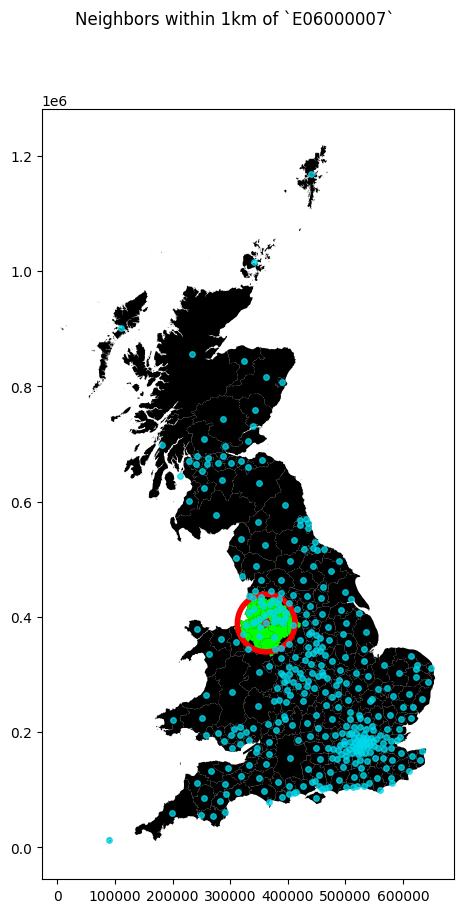

In [29]:
w = weights.Queen.from_dataframe(br, idVariable='LAD14CD')

# Row standardize the matrix
w.transform = 'R'

imd=br.to_crs(epsg=27700)
knn5 = weights.KNN.from_dataframe(imd, k=5)
import numpy as np
cents = imd.centroid
pts = np.array([(pt.x, pt.y) for pt in cents]) # Extract coordinates into an array
knn5_from_pts = weights.KNN.from_array(pts, k=5) # Compute KNN weights
knn5_from_pts

cents = imd.centroid
pts = np.array([(pt.x, pt.y) for pt in cents]) # Extract coordinates into an array
knn5_from_pts = weights.KNN.from_array(pts, k=5) # Compute KNN weights
knn5_from_pts

w_dist50kmB = weights.DistanceBand.from_dataframe(imd, 50000)
w_dist50kmB['E06000007']

w_dist50kmC = weights.DistanceBand.from_dataframe(imd, 50000, binary=False)
w_dist50kmC['E06000007']

# Setup figure
f, ax = plt.subplots(1, figsize=(10, 10))

# Plot base layer of polygons
imd.plot(ax=ax, facecolor='k', linewidth=0.1)

# Select focal polygon
focus = imd.loc[['E06000007'], ['geometry']]

# Plot focal polygon
focus.plot(facecolor='red', alpha=1, linewidth=0, ax=ax)

# Convert neighbors to list if necessary
neighbors_list = list(w_dist50kmC['E06000007'])

# Plot neighbors
neis = imd.loc[neighbors_list, :]
neis.plot(ax=ax, facecolor='lime', linewidth=0)

# Plot 1km buffer
buf = focus.centroid.buffer(50000)
buf.plot(edgecolor='red', facecolor='none', ax=ax, linewidth=4)

# Plot centroids of neighbor
pts = np.array([(pt.x, pt.y) for pt in imd.centroid])
ax.plot(pts[:, 0], pts[:, 1], color='#00d8ea', 
        linewidth=0, alpha=0.75, marker='o', markersize=4)

# Title
f.suptitle("Neighbors within 1km of `E06000007`")

# Display
plt.show()

In [33]:
br['w_Pct_Leave'] = weights.lag_spatial(w, br['Pct_Leave'])
br[['LAD14NM', 'Pct_Leave', 'w_Pct_Leave']].head()
neis = br.loc[w.neighbors['E06000001'], 'Pct_Leave']
br['Pct_Leave_std'] = (br['Pct_Leave'] - br['Pct_Leave'].mean()) / br['Pct_Leave'].std()
br['w_Pct_Leave_std'] = weights.lag_spatial(w, br['Pct_Leave_std'])

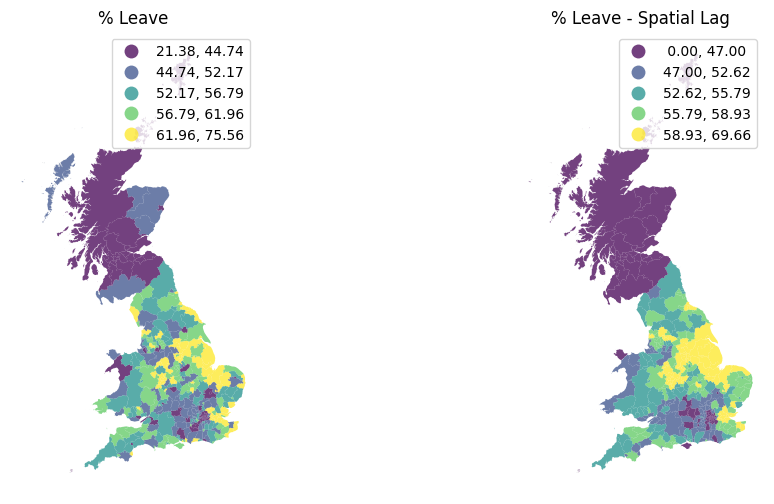

In [34]:
f, axs = plt.subplots(1, 2, figsize=(12, 6))
ax1, ax2 = axs
br.plot(column='Pct_Leave', cmap='viridis', scheme='quantiles',k=5, edgecolor='white', linewidth=0., alpha=0.75, legend=True, ax=ax1)
ax1.set_axis_off()
ax1.set_title("% Leave")
br.plot(column='w_Pct_Leave', cmap='viridis', scheme='quantiles',k=5, edgecolor='white', linewidth=0., alpha=0.75, legend=True, ax=ax2)
ax2.set_axis_off()
ax2.set_title("% Leave - Spatial Lag")
plt.show()

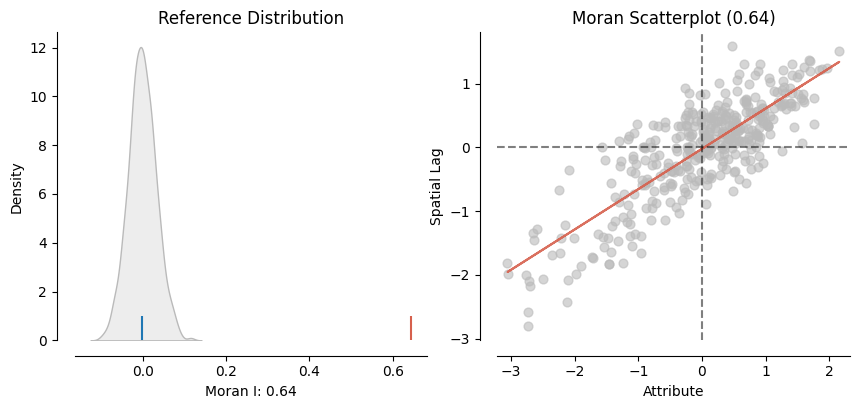

In [41]:
import esda
mi = esda.Moran(br['Pct_Leave'], w)
mi.I
mi.p_sim


# from libpysal.viz import splot
from splot.esda import plot_moran
plot_moran(mi);

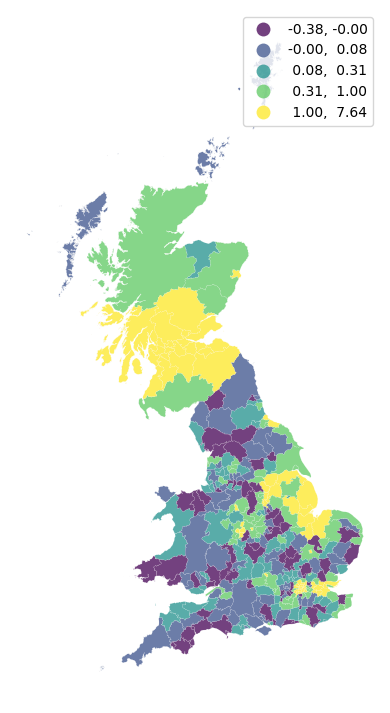

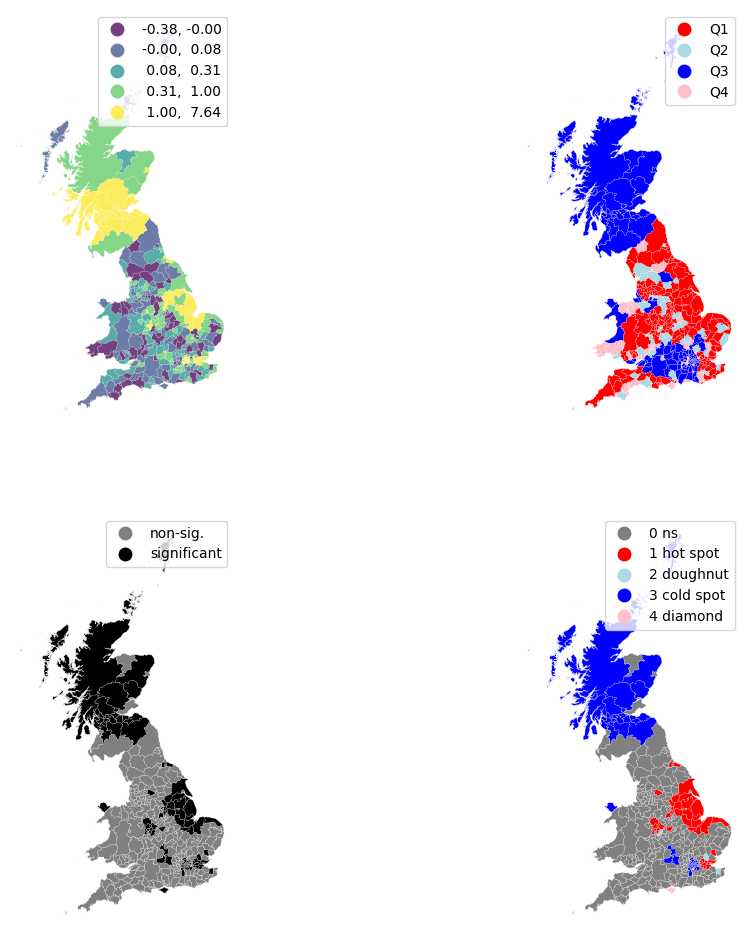

In [42]:
lisa = esda.Moran_Local(br['Pct_Leave'], w)
f, ax = plt.subplots(1, figsize=(9,9))
br['Is'] = lisa.Is
br.plot(column='Is', cmap='viridis', scheme='quantiles',k=5, edgecolor='white', linewidth=0.1, alpha=0.75, legend=True,ax=ax);
ax.set_axis_off()

from matplotlib.colors import ListedColormap
# Set up figure and axes
f, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))
# Make the axes accessible with single indexing
axs = axs.flatten()

                    # Subplot 1 #
ax = axs[0]
br.plot(column='Is', cmap='viridis', scheme='quantiles',
        k=5, edgecolor='white', linewidth=0.1, alpha=0.75, legend=True, ax=ax)
ax.set_aspect('equal')
ax.set_axis_off()

                    # Subplot 2 #
ax = axs[1]
q_labels = ['Q1', 'Q2', 'Q3', 'Q4']
labels = [q_labels[i-1] for i in lisa.q]
hmap = ListedColormap([ 'red', 'lightblue', 'blue', 'pink'])
br.assign(cl=labels).plot(column='cl', categorical=True, \
        k=2, cmap=hmap, linewidth=0.1, ax=ax, \
        edgecolor='white', legend=True)

ax.set_aspect('equal')
ax.set_axis_off()

                    # Subplot 3 #

ax = axs[2]
sig = 1 * (lisa.p_sim < 0.05)
hmap = ListedColormap(['grey','black'])
labels = ['non-sig.', 'significant'] 
labels = [labels[i] for i in sig]
br.assign(cl=labels).plot(column='cl', categorical=True, \
        k=2, cmap=hmap, linewidth=0.1, ax=ax, \
        edgecolor='white', legend=True)

ax.set_aspect('equal')
ax.set_axis_off()
                            
                    # Subplot 4 #
ax = axs[3]
hotspot = 1 * (sig * lisa.q==1)
coldspot = 3 * (sig * lisa.q==3)
doughnut = 2 * (sig * lisa.q==2)
diamond = 4 * (sig * lisa.q==4)
spots = hotspot + coldspot + doughnut + diamond
spot_labels = [ '0 ns', '1 hot spot', '2 doughnut', '3 cold spot', '4 diamond']
labels = [spot_labels[i] for i in spots]
hmap = ListedColormap([ 'grey', 'red', 'lightblue', 'blue', 'pink'])


br.assign(cl=labels).plot(column='cl', categorical=True, \
        k=2, cmap=hmap, linewidth=0.1, ax=ax, \
        edgecolor='white', legend=True)

ax.set_aspect('equal')
ax.set_axis_off()


# Display the figure
plt.show()

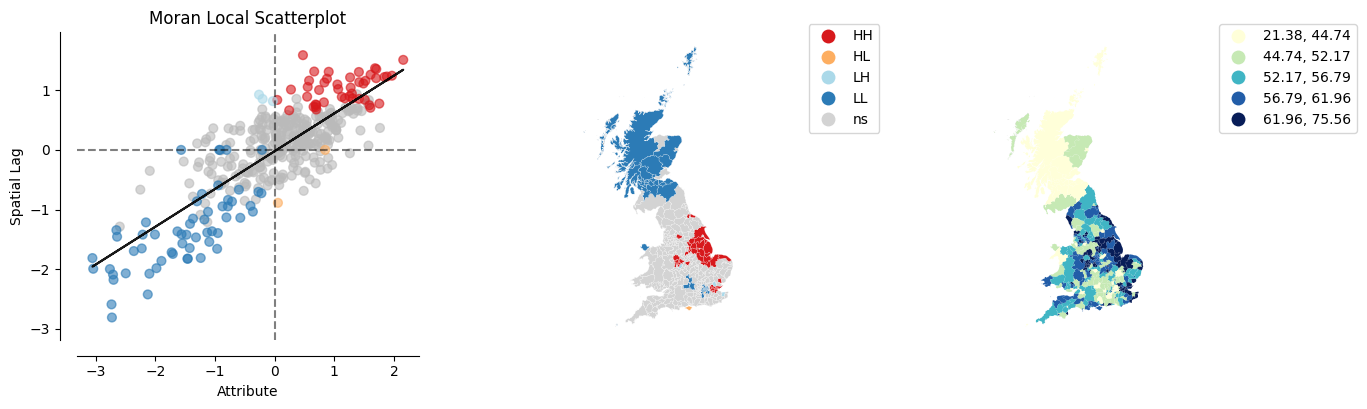

In [43]:
from splot.esda import plot_local_autocorrelation
plot_local_autocorrelation(lisa, br, 'Pct_Leave');